Alfred at your service. As Mr. Wayne’s trusted butler, I’ve taken the liberty of documenting how I assist Mr Wayne with his various documentary needs. While he’s out attending to his… nighttime activities, I ensure all his paperwork, training schedules, and nutritional plans are properly analyzed and organized.

Before leaving, he left a note with his week’s training program. I then took the responsibility to come up with a menu for tomorrow’s meals.

For future such events, let’s create a document analysis system using LangGraph to serve Mr. Wayne’s needs. This system can:
1. Process images document
2. Extract text using vision models (Vision Language Model)
3. Perform calculations when needed (to demonstrate normal tools)
4. Analyze content and provide concise summaries
5. Execute specific instructions related to documents

In [41]:
!pip install langgraph langchain_openai langchain_core

In [95]:
!pip install -U langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.59.0 which is incompatible.
google-adk 2.7.1 requires opentelemetry-api<=1.42.1

In [100]:
import base64
from typing import List, TypedDict, Annotated, Optional
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
import os
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
os.environ["HF_TOKEN"] = HF_TOKEN
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

### Defining Agent’s State
This state is a little more complex than the previous ones we have seen. AnyMessage is a class from Langchain that defines messages, and add_messages is an operator that adds the latest message rather than overwriting it with the latest state.


In [101]:
class AgentState(TypedDict):
    # The document provided
    input_file : Optional[str] # Contains file path (PDF/PNG)
    messages: Annotated[list[AnyMessage] , add_messages]

In [128]:
# Preparing tools

import mimetypes

vision_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    google_api_key=GEMINI_API_KEY
)

def extract_text(img_path: str) -> str:
    """
    Extract all visible text from an image file using Gemini vision.

    Args:
        img_path: Path to the image file.

    Returns:
        The text extracted from the image.
    """
    try:
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        mime_type, _ = mimetypes.guess_type(img_path)

        if mime_type is None:
            mime_type = "image/png"

        message = HumanMessage(
            content=[
                {
                    "type": "text",
                    "text": (
                        "Extract all the text from this image. "
                        "Return only the extracted text."
                    ),
                },
                {
                    "type": "image_url",
                    "image_url": (
                        f"data:{mime_type};base64,{image_base64}"
                    ),
                },
            ]
        )

        response = vision_llm.invoke([message])

        # Gemini may return content as a list
        if isinstance(response.content, list):
            text_parts = []

            for item in response.content:
                if isinstance(item, str):
                    text_parts.append(item)
                elif isinstance(item, dict):
                    if "text" in item:
                        text_parts.append(item["text"])

            return "\n".join(text_parts).strip()

        return str(response.content).strip()

    except Exception as e:
        print(f"Error extracting text: {type(e).__name__}: {e}")
        return ""

def divide(a: int, b: int) -> float:
    """Divide a and b - for Master Wayne's occasional calculations."""
    return a / b

# Equip the butler with tools
tools = [
    divide,
    extract_text
]

llm = HuggingFaceEndpoint(
    # repo_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    repo_id="openai/gpt-oss-120b",
    task="text-generation",
    max_new_tokens=512,
    temperature=0.1,
    huggingfacehub_api_token=HF_TOKEN
)

chat_llm = ChatHuggingFace(llm=llm)
llm_with_tools = chat_llm.bind_tools(
    tools,
    # parallel_tool_calls=False
)

In [129]:
# The nodes

def assistant(state: AgentState):
    # System message
    textual_description_of_tool="""
extract_text(img_path: str) -> str:
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
divide(a: int, b: int) -> float:
    Divide a and b
"""
    image=state["input_file"]
    sys_msg = SystemMessage(content=f"You are a helpful butler named Alfred that serves Mr. Wayne and Batman. You can analyse documents and run computations with provided tools:\n{textual_description_of_tool} \n You have access to some optional images. Currently the loaded image is: {image}")

    return {
        "messages": [llm_with_tools.invoke([sys_msg] + state["messages"])],
        "input_file": state["input_file"]
    }

### The ReAct Pattern: How I Assist Mr. Wayne
Allow me to explain the approach in this agent. The agent follows what’s known as the ReAct pattern (Reason-Act-Observe)
1. **Reason** about his documents and requests
2. **Act** by using appropriate tools
3. **Observe** the results
4. **Repeat** as necessary until I’ve fully addressed his needs

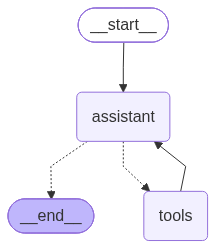

In [130]:
# The graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message requires a tool, route to tools
    # Otherwise, provide a direct response
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show the butler's thought process
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [111]:
# example 1

messages = [HumanMessage(content="Divide 6790 by 5")]
messages = react_graph.invoke({"messages": messages, "input_file": None})

# Show the messages
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide 6790 by 5
================================== Ai Message ==================================
Tool Calls:
  divide (9bad38ba6)
 Call ID: 9bad38ba6
  Args:
    a: 6790
    b: 5
================================= Tool Message =================================
Name: divide

1358.0
================================== Ai Message ==================================

The result of dividing 6790 by 5 is **1358.0**.


In [132]:
# example 2

# messages = [HumanMessage(content="According to the note provided by Mr. Wayne in the provided images. What's the list of items I should buy for the dinner menu?")]
# messages = react_graph.invoke({"messages": messages, "input_file": "/content/Gemini_Generated_Image_wmqog2wmqog2wmqo.png"})

image_path = "/content/Gemini_Generated_Image_wmqog2wmqog2wmqo.png"

text = extract_text(image_path)

print("EXTRACTED TEXT:")
print(text)


EXTRACTED TEXT:
Dinner Shopping List
Chicken
Rice
Onions
Tomatoes
Garlic
Salt
Pepper
Cooking oil


In [133]:
result = llm_with_tools.invoke([
    HumanMessage(
        content="""
Here is the text extracted from Mr. Wayne's note:

Dinner Shopping List
Chicken
Rice
Onions
Tomatoes
Garlic
Salt
Pepper
Cooking oil

According to this note, what items should I buy for the dinner menu?
"""
    )
])

result.pretty_print()


================================== Ai Message ==================================

Based on Mr. Wayne’s note, you should purchase the following items for the dinner menu:

1. Chicken  
2. Rice  
3. Onions  
4. Tomatoes  
5. Garlic  
6. Salt  
7. Pepper  
8. Cooking oil  

These eight ingredients cover the entire list he wrote. Happy shopping!
